In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast, re
import seaborn as sns

In [37]:
results = pd.read_csv('../data/amplicon_architect_aa_result_table_consensus.tsv', sep='\t')
print(f"Total samples: {results['Sample name'].nunique()}")
print(f"Events: {results['Classification'].value_counts()}\n")

# Filter to ecDNA events
ecDNA = results[results['Classification'] == 'ecDNA'] 
ecDNA.to_csv('../data/ecDNA_results.tsv', sep='\t')
print(f"Samples with ecDNA: {ecDNA['Sample name'].nunique()}")
print(f"Events: {ecDNA['ecDNA context'].value_counts()}\n")
ecDNA.head()

Total samples: 192
Events: Classification
Linear                407
Complex-non-cyclic    229
ecDNA                 201
BFB                    15
Name: count, dtype: int64

Samples with ecDNA: 98
Events: ecDNA context
Unknown                                67
Heavily rearranged multichromosomal    43
Simple circular complex background     34
Heavily rearranged unichromosomal      30
Two-foldback                           16
Simple circular simple background       6
BFB-like                                5
Name: count, dtype: int64



,Sample name,AA amplicon number,Feature ID,Classification,Location,Oncogenes,All genes,NCBI Gene IDs,Complexity score,ecDNA context,...,Feature BED file,CNV BED file,AS-p version,AA version,AC version,AA PNG file,AA PDF file,AA summary file,Run metadata JSON,Sample metadata JSON
1,09T02,3.0,09T02_amplicon3_ecDNA_1,ecDNA,['chr19:12293891-12440217'],[],"['ZNF44', 'ZNF442', 'ZNF443', 'ZNF563', 'ZNF799']","['NM_001353551', 'NM_030824', 'NM_005815', 'NM...",0.565933,Unknown,...,/mnt/disks/cromwell_root/09T02_classification/...,Not provided,1.5.1,1.5.r5,1.5.1,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_run_metadata.json,/mnt/disks/cromwell_root/09T02_sample_metadata...
2,09T02,3.0,09T02_amplicon3_ecDNA_2,ecDNA,"['chr19:10110051-10110079', 'chr19:10428908-10...","['DNM2', 'SMARCA4']","['AP1M2', 'ATG4D', 'CDKN2D', 'DNM2', 'ILF3', '...","['NM_005498', 'NR_104025', 'NM_001800', 'NM_00...",0.998827,Heavily rearranged multichromosomal,...,/mnt/disks/cromwell_root/09T02_classification/...,Not provided,1.5.1,1.5.r5,1.5.1,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_run_metadata.json,/mnt/disks/cromwell_root/09T02_sample_metadata...
3,09T02,4.0,09T02_amplicon4_ecDNA_1,ecDNA,"['chr8:117647510-117648469', 'chr8:117648607-1...",['EXT1'],['EXT1'],['NM_000127'],0.512751,Unknown,...,/mnt/disks/cromwell_root/09T02_classification/...,Not provided,1.5.1,1.5.r5,1.5.1,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_run_metadata.json,/mnt/disks/cromwell_root/09T02_sample_metadata...
4,09T03,1.0,09T03_amplicon1_ecDNA_1,ecDNA,"['chr19:10455066-10840920', 'chr19:11465100-12...","['CALR', 'DNM2', 'JUNB', 'LYL1']","['ACP5', 'ADGRE2', 'ADGRE3', 'AP1M2', 'ATG4D',...","['NM_001611', 'NM_013447', 'NM_001289159', 'NM...",0.710648,Heavily rearranged multichromosomal,...,/mnt/disks/cromwell_root/09T03_classification/...,Not provided,1.5.1,1.5.r5,1.5.1,/mnt/disks/cromwell_root/09T03_AA_results/09T0...,/mnt/disks/cromwell_root/09T03_AA_results/09T0...,/mnt/disks/cromwell_root/09T03_AA_results/09T0...,/mnt/disks/cromwell_root/09T03_run_metadata.json,/mnt/disks/cromwell_root/09T03_sample_metadata...
9,10T03,5.0,10T03_amplicon5_ecDNA_1,ecDNA,"['chr8:133866577-134070686', 'chr8:134076772-1...",[],"['ZFAT', 'ZFAT-AS1']","['NM_001174158', 'NR_002438']",0.683730,Simple circular simple background,...,/mnt/disks/cromwell_root/10T03_classification/...,Not provided,1.5.1,1.5.r5,1.5.1,/mnt/disks/cromwell_root/10T03_AA_results/10T0...,/mnt/disks/cromwell_root/10T03_AA_results/10T0...,/mnt/disks/cromwell_root/10T03_AA_results/10T0...,/mnt/disks/cromwell_root/10T03_run_metadata.json,/mnt/disks/cromwell_root/10T03_sample_metadata...


In [ ]:
# Filter to samples in final_samples (unique patient samples)
final_samples = pd.read_csv("../../SV_sample_data/data/final_analysis_samples.csv")

def extract_tumor_id(row):
    pair = row['tumor_normal_pair']
    cohort = row['cohort']
    
    if cohort.startswith('TARGET'):
        # Tumor sample ends with '-01A'
        import re
        match = re.search(r'.*-01A', pair)
        if match:
            return match.group(0)
        else:
            print("not correctly formatted")
            return pair
    else:
        return pair.split('-', 1)[0]

final_samples['tumor_id'] = final_samples.apply(extract_tumor_id, axis=1)
final_samples_list = final_samples['tumor_id'].to_list()

In [39]:
results_filtered = results[results['Sample name'].isin(final_samples_list)]
print(f"Total unique patient samples: {results_filtered['Sample name'].nunique()}")

ecDNA_filtered = ecDNA[ecDNA['Sample name'].isin(final_samples_list)]
print(f"Unique patient samples with ecDNA: {ecDNA_filtered['Sample name'].nunique()}")
print(f"Events: {ecDNA_filtered['ecDNA context'].value_counts()}\n")
ecDNA_filtered.head()


Total unique patient samples: 166
Unique patient samples with ecDNA: 79
Events: ecDNA context
Unknown                                57
Heavily rearranged multichromosomal    32
Simple circular complex background     28
Heavily rearranged unichromosomal      23
Two-foldback                           14
Simple circular simple background       5
BFB-like                                3
Name: count, dtype: int64



,Sample name,AA amplicon number,Feature ID,Classification,Location,Oncogenes,All genes,NCBI Gene IDs,Complexity score,ecDNA context,...,Feature BED file,CNV BED file,AS-p version,AA version,AC version,AA PNG file,AA PDF file,AA summary file,Run metadata JSON,Sample metadata JSON
1,09T02,3.0,09T02_amplicon3_ecDNA_1,ecDNA,['chr19:12293891-12440217'],[],"['ZNF44', 'ZNF442', 'ZNF443', 'ZNF563', 'ZNF799']","['NM_001353551', 'NM_030824', 'NM_005815', 'NM...",0.565933,Unknown,...,/mnt/disks/cromwell_root/09T02_classification/...,Not provided,1.5.1,1.5.r5,1.5.1,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_run_metadata.json,/mnt/disks/cromwell_root/09T02_sample_metadata...
2,09T02,3.0,09T02_amplicon3_ecDNA_2,ecDNA,"['chr19:10110051-10110079', 'chr19:10428908-10...","['DNM2', 'SMARCA4']","['AP1M2', 'ATG4D', 'CDKN2D', 'DNM2', 'ILF3', '...","['NM_005498', 'NR_104025', 'NM_001800', 'NM_00...",0.998827,Heavily rearranged multichromosomal,...,/mnt/disks/cromwell_root/09T02_classification/...,Not provided,1.5.1,1.5.r5,1.5.1,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_run_metadata.json,/mnt/disks/cromwell_root/09T02_sample_metadata...
3,09T02,4.0,09T02_amplicon4_ecDNA_1,ecDNA,"['chr8:117647510-117648469', 'chr8:117648607-1...",['EXT1'],['EXT1'],['NM_000127'],0.512751,Unknown,...,/mnt/disks/cromwell_root/09T02_classification/...,Not provided,1.5.1,1.5.r5,1.5.1,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_AA_results/09T0...,/mnt/disks/cromwell_root/09T02_run_metadata.json,/mnt/disks/cromwell_root/09T02_sample_metadata...
9,10T03,5.0,10T03_amplicon5_ecDNA_1,ecDNA,"['chr8:133866577-134070686', 'chr8:134076772-1...",[],"['ZFAT', 'ZFAT-AS1']","['NM_001174158', 'NR_002438']",0.683730,Simple circular simple background,...,/mnt/disks/cromwell_root/10T03_classification/...,Not provided,1.5.1,1.5.r5,1.5.1,/mnt/disks/cromwell_root/10T03_AA_results/10T0...,/mnt/disks/cromwell_root/10T03_AA_results/10T0...,/mnt/disks/cromwell_root/10T03_AA_results/10T0...,/mnt/disks/cromwell_root/10T03_run_metadata.json,/mnt/disks/cromwell_root/10T03_sample_metadata...
28,17_439_00067_T2,2.0,17_439_00067_T2_amplicon2_ecDNA_2,ecDNA,"['chr1:156687531-157192948', 'chr1:157213273-1...","['ETV3', 'NTRK1', 'PRCC']","['ABCC4', 'ARHGEF11', 'CLDN10', 'CLDN10-AS1', ...","['NM_005845', 'NM_014784', 'NM_182848', 'NR_04...",0.553692,Unknown,...,/mnt/disks/cromwell_root/17_439_00067_T2_class...,Not provided,1.5.1,1.5.r5,1.5.1,/mnt/disks/cromwell_root/17_439_00067_T2_AA_re...,/mnt/disks/cromwell_root/17_439_00067_T2_AA_re...,/mnt/disks/cromwell_root/17_439_00067_T2_AA_re...,/mnt/disks/cromwell_root/17_439_00067_T2_run_m...,/mnt/disks/cromwell_root/17_439_00067_T2_sampl...


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_66528/590895854.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecDNA_filtered["Location_list"] = ecDNA_filtered["Location"].apply(ast.literal_eval)


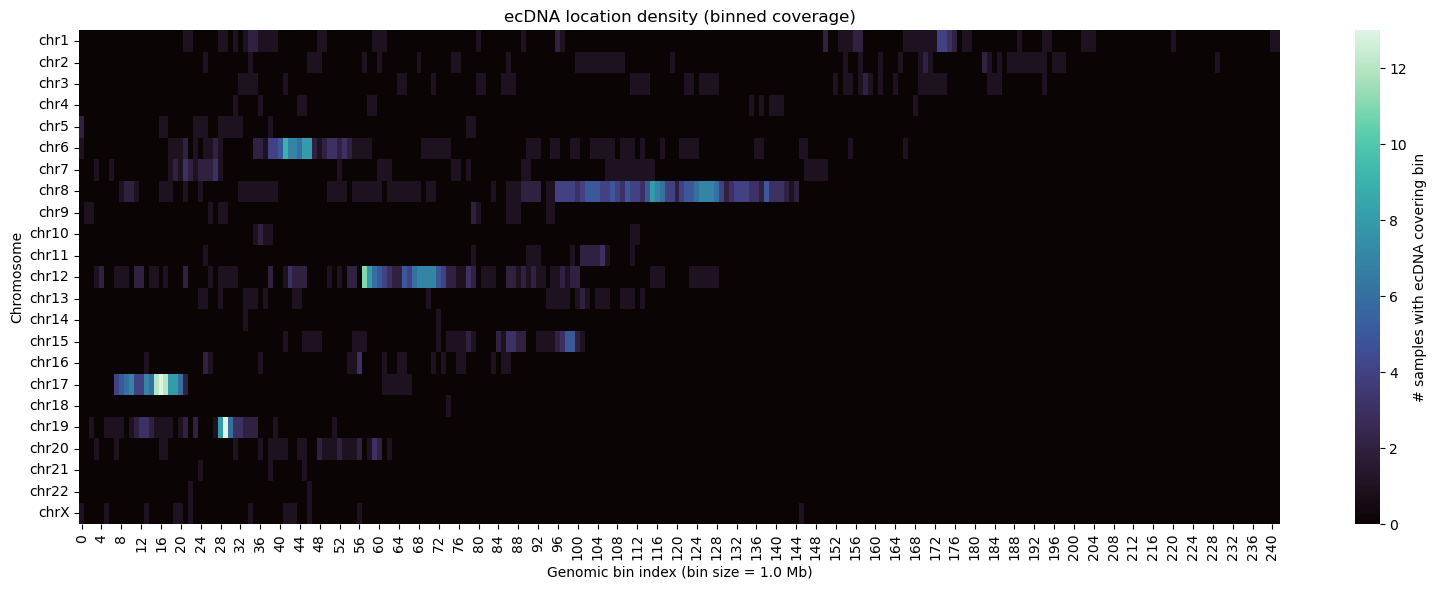

In [40]:
# Parse "['chr8:1-2', ...]" -> list[str]
ecDNA_filtered["Location_list"] = ecDNA_filtered["Location"].apply(ast.literal_eval)

pat = re.compile(r"^(chr[0-9XYM]+):(\d+)-(\d+)$")

def parse_seg(seg_str):
    m = pat.match(seg_str)
    if not m:
        return None
    chrom, s, e = m.group(1), int(m.group(2)), int(m.group(3))
    if e < s:
        s, e = e, s
    return chrom, s, e

rows = []
for sample, fid, locs in zip(ecDNA_filtered["Sample name"], ecDNA_filtered["Feature ID"], ecDNA_filtered["Location_list"]):
    for s in locs:
        parsed = parse_seg(s)
        if parsed is None:
            continue
        chrom, start, end = parsed
        rows.append((sample, fid, chrom, start, end))

seg = pd.DataFrame(rows, columns=["Sample name", "Feature ID", "chrom", "start", "end"])

BIN = 1_000_000 
seg["bin_start"] = (seg["start"] // BIN).astype(int)
seg["bin_end"]   = ((seg["end"] - 1) // BIN).astype(int)

# Count unique ecDNA events covering each bin 
bin_hits = []
for sid, fid, chrom, b0, b1 in seg[["Sample name", "Feature ID","chrom","bin_start","bin_end"]].itertuples(index=False):
    for b in range(b0, b1 + 1):
        bin_hits.append((chrom, b, fid, sid))
bin_hits = pd.DataFrame(bin_hits, columns=["chrom","bin","Feature ID", "Sample name"]).drop_duplicates()

counts = (
    bin_hits.groupby(["chrom","bin"])["Sample name"]
    .nunique()
    .reset_index(name="n_samples")
)

# Make a rectangular chrom x bin matrix (pad missing bins with 0)
chrom_order = [f"chr{i}" for i in range(1,23)] + ["chrX","chrY"]
chrom_order = [c for c in chrom_order if c in counts["chrom"].unique()]

max_bin = counts["bin"].max()
mat = (
    counts.pivot(index="chrom", columns="bin", values="n_samples")
    .reindex(index=chrom_order, columns=range(max_bin + 1))
    .fillna(0)
)

counts["window_start_bp"] = counts["bin"] * BIN
counts["window_end_bp"]   = counts["window_start_bp"] + BIN
counts.to_csv("../results/ecdna_windows.csv", index=False)

plt.figure(figsize=(16, 6))
sns.heatmap(mat, cmap="mako", cbar_kws={"label": "# samples with ecDNA covering bin"})
plt.xlabel(f"Genomic bin index (bin size = {BIN/1e6:.1f} Mb)")
plt.ylabel("Chromosome")
plt.title("ecDNA location density (binned coverage)")
plt.tight_layout()
plt.show()

In [41]:
events_df = pd.read_csv('../../SV_signature_analysis/Clustered_SVs/results/hotspot_event_definitions.csv')
events_df['chrom'] = events_df['chrom'].astype(str)
events = (
    events_df
    .set_index('event')[['chrom', 'start', 'end']]
    .to_dict(orient='index')
)

def overlaps_region(seg, region_chr, region_start, region_end):
    chrom, s, e = seg
    return (chrom == region_chr) and (s <= region_end) and (e >= region_start)

# Add one column per event
for event_name, region in events.items():
    region_chr = f"chr{region['chrom']}"
    region_start, region_end = region["start"], region["end"]

    col = f"overlaps_{event_name}"
    ecDNA_filtered[col] = ecDNA_filtered["Location_list"].apply(
        lambda segs: any(
            (parsed := parse_seg(s)) is not None and overlaps_region(parsed, region_chr, region_start, region_end)
            for s in segs
        )
    )

ecDNA_filtered = ecDNA_filtered[['Sample name', 'Feature ID', 'ecDNA context', 'Feature maximum copy number', 'Filter flag', 'Oncogenes', 'All genes', 'Location_list', 'overlaps_CCND3', 'overlaps_MYC', 'overlaps_CDK4-MDM2', 'overlaps_CCNE1', 'overlaps_TP53']]
ecDNA_filtered.to_csv('../results/ecDNA_hotspot_overlap.tsv', sep='\t')
ecDNA_filtered.head()

/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_66528/3914870501.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecDNA_filtered[col] = ecDNA_filtered["Location_list"].apply(
/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_66528/3914870501.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecDNA_filtered[col] = ecDNA_filtered["Location_list"].apply(
/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_66528/3914870501.py:19: SettingWithCopyWarning: 
A value is trying to be 

,Sample name,Feature ID,ecDNA context,Feature maximum copy number,Filter flag,Oncogenes,All genes,Location_list,overlaps_CCND3,overlaps_MYC,overlaps_CDK4-MDM2,overlaps_CCNE1,overlaps_TP53
1,09T02,09T02_amplicon3_ecDNA_1,Unknown,11.244598,NaN,[],"['ZNF44', 'ZNF442', 'ZNF443', 'ZNF563', 'ZNF799']",[chr19:12293891-12440217],False,False,False,False,False
2,09T02,09T02_amplicon3_ecDNA_2,Heavily rearranged multichromosomal,6.469511,LowCN,"['DNM2', 'SMARCA4']","['AP1M2', 'ATG4D', 'CDKN2D', 'DNM2', 'ILF3', '...","[chr19:10110051-10110079, chr19:10428908-10841...",False,False,False,False,False
3,09T02,09T02_amplicon4_ecDNA_1,Unknown,4.991703,LowCN,['EXT1'],['EXT1'],"[chr8:117647510-117648469, chr8:117648607-1178...",False,True,False,False,False
9,10T03,10T03_amplicon5_ecDNA_1,Simple circular simple background,7.360562,NaN,[],"['ZFAT', 'ZFAT-AS1']","[chr8:133866577-134070686, chr8:134076772-1344...",False,True,False,False,False
28,17_439_00067_T2,17_439_00067_T2_amplicon2_ecDNA_2,Unknown,9.365813,NaN,"['ETV3', 'NTRK1', 'PRCC']","['ABCC4', 'ARHGEF11', 'CLDN10', 'CLDN10-AS1', ...","[chr1:156687531-157192948, chr1:157213273-1575...",False,False,False,False,False


In [42]:
overlap_cols = [c for c in ecDNA_filtered.columns if c.startswith("overlaps_")]
n_hotspots = ecDNA_filtered[overlap_cols].astype(int).sum(axis=1)

ecDNA_cooccurrence = ecDNA_filtered[
    (n_hotspots > 1) & (ecDNA_filtered["overlaps_TP53"].astype(int) == 1)
].copy()
ecDNA_cooccurrence

,Sample name,Feature ID,ecDNA context,Feature maximum copy number,Filter flag,Oncogenes,All genes,Location_list,overlaps_CCND3,overlaps_MYC,overlaps_CDK4-MDM2,overlaps_CCNE1,overlaps_TP53
493,SJOS001126_D1,SJOS001126_D1_amplicon5_ecDNA_1,Heavily rearranged multichromosomal,51.070935,NaN,"['CCNE1', 'COPS3', 'SREBF1', 'URI1']","['ADORA2B', 'ALKBH5', 'ANKRD27', 'ATPAF2', 'C1...","[chr19:28631495-29897897, chr19:29902193-31476...",False,False,False,True,True
525,SJOS004_D,SJOS004_D_amplicon1_ecDNA_1,Simple circular complex background,19.873550,NaN,[],"['C19orf12', 'PLEKHF1', 'POP4', 'SHISA6', 'UQC...","[chr19:28713742-29730394, chr17:11317446-11317...",False,False,False,True,True
622,SJOS014_D,SJOS014_D_amplicon1_ecDNA_2,Heavily rearranged multichromosomal,11.290534,NaN,['TRIB1'],"['ANXA13', 'ATAD2', 'C8orf76', 'DERL1', 'FAM83...","[chr8:122875218-125582885, chr8:125588890-1261...",False,True,False,False,True
656,SJOS030101_D2,SJOS030101_D2_amplicon1_ecDNA_4,Heavily rearranged multichromosomal,25.720431,NaN,"['CDC5L', 'COPS3', 'DNPH1', 'PTK7', 'SREBF1', ...","['AARS2', 'ABCC10', 'ACVR1', 'ADCY10P1', 'ADOR...","[chr2:154963015-154967946, chr2:157669865-1578...",True,False,False,False,True
666,SJOS030272_D1,SJOS030272_D1_amplicon10_ecDNA_1,Heavily rearranged multichromosomal,22.688145,NaN,"['ADGRF1', 'CCND3', 'CDC5L', 'CUL7', 'DNPH1', ...","['AARS2', 'ABCC10', 'ADCY10P1', 'ADGRF1', 'ADG...","[chr6:35430223-35658657, chr6:35661967-3635168...",True,False,False,False,True
694,SJOS030589_D3,SJOS030589_D3_amplicon1_ecDNA_2,Heavily rearranged multichromosomal,44.275967,NaN,"['AKAP13', 'CCN3', 'CCN4', 'EXT1', 'HAX1', 'HM...","['ADCY8', 'AEN', 'AGBL1', 'AGBL1-AS1', 'AKAP13...","[chr8:115916213-115916478, chr8:116024095-1160...",False,True,False,False,True
741,SJOS031125_D1,SJOS031125_D1_amplicon5_ecDNA_1,Heavily rearranged multichromosomal,17.597650,NaN,"['AGAP2', 'CCND3', 'CDC5L', 'CDK4', 'DCD', 'DD...","['AARS2', 'ABCC10', 'ADAMTS20', 'ADPRM', 'AGAP...","[chr12:38434229-38434230, chr12:42435728-43583...",True,False,True,False,True


In [43]:
# overall, what are the top oncogenes in ecDNA?
def as_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x) or x == "" or x == "[]":
        return []
    return ast.literal_eval(x)

oncogene_counts = (
    ecDNA_filtered["Oncogenes"]
    .apply(as_list)
    .explode()
    .dropna()
    .value_counts()
)

print("Top oncogenes in ecDNA (by # events):")
print(oncogene_counts.head(25).to_string())

Top oncogenes in ecDNA (by # events):
Oncogenes
AGAP2     11
CDK4      11
CCNE1      9
TFEB       8
YEATS4     7
COPS3      7
CCND3      6
MYC        6
GLI1       6
CDC5L      6
SREBF1     6
MDM2       6
EXT1       6
TRIB1      5
DDIT3      5
IFNG       5
DNPH1      5
URI1       5
LRIG3      5
IGF1R      5
PVT1       5
EIF3E      4
RAD21      4
UBR5       4
PTK7       4


In [44]:
clustered_sv = pd.read_csv('../../SV_signature_analysis/Clustered_SVs/results/clustered_sv_merged_hotspot_matrix.csv')

# rename sample_id to tumor_normal_pair
clustered_sv = clustered_sv.rename(columns={'sample_id': 'tumor_normal_pair'})

# merge cohort column from final_samples
final_samples_list = final_samples['tumor_normal_pair'].to_list()
clustered_sv = clustered_sv[clustered_sv['tumor_normal_pair'].isin(final_samples_list)]
clustered_sv = clustered_sv.merge(final_samples[['tumor_normal_pair', 'cohort']], on='tumor_normal_pair', how='left')

# extract just the tumor name to match formatting with aa results
clustered_sv['tumor_id'] = clustered_sv.apply(extract_tumor_id, axis=1)

# filter clustered sv data to only include samples in aa results
results_filtered_sample_list = results_filtered['Sample name'].to_list()
clustered_sv = clustered_sv[clustered_sv['tumor_id'].isin(results_filtered_sample_list)]
print(len(clustered_sv))
clustered_sv.head()

166


,tumor_normal_pair,CCND3,MYC,CDK4-MDM2,CCNE1,TP53,n_clustered_events,cohort,tumor_id
0,09T02-09N01,0,1,0,0,0,8,DFCI_from_CZ_Zhang,09T02
1,10T03-10N02,0,0,0,0,0,2,DFCI_from_CZ_Zhang,10T03
2,13T02-13N02,0,0,1,1,0,8,DFCI_from_CZ_Zhang,13T02
3,17_439_00067_T2-17_439_00067_WB,0,0,0,0,0,3,DFCI_with_snRNAseq,17_439_00067_T2
5,CCG1106_005_T1-CCG1106_005_WB,0,0,0,0,1,12,DFCI_with_snRNAseq,CCG1106_005_T1


In [45]:
overlap_cols = [c for c in ecDNA_filtered.columns if c.startswith("overlaps_")]

sample_hotspot = (
    ecDNA_filtered
    .groupby("Sample name")[overlap_cols]
    .any() # True if sample has ≥1 ecDNA event overlapping that hotspot
    .reset_index()
)

clustered_sv = clustered_sv.merge(sample_hotspot, left_on="tumor_id", right_on="Sample name", how="left")
clustered_sv[overlap_cols] = clustered_sv[overlap_cols].fillna(False)
clustered_sv = clustered_sv.drop(columns=["Sample name"])
clustered_sv = clustered_sv.rename(columns={c: c.replace("overlaps_", "ecDNA_", 1) for c in overlap_cols})
ecdna_cols = [c for c in clustered_sv.columns if c.startswith("ecDNA_")]
clustered_sv[ecdna_cols] = clustered_sv[ecdna_cols].astype(int)
clustered_sv.to_csv('../results/ecDNA_matrix.csv')
clustered_sv.head()

/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_66528/4206740172.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clustered_sv[overlap_cols] = clustered_sv[overlap_cols].fillna(False)


,tumor_normal_pair,CCND3,MYC,CDK4-MDM2,CCNE1,TP53,n_clustered_events,cohort,tumor_id,ecDNA_CCND3,ecDNA_MYC,ecDNA_CDK4-MDM2,ecDNA_CCNE1,ecDNA_TP53
0,09T02-09N01,0,1,0,0,0,8,DFCI_from_CZ_Zhang,09T02,0,1,0,0,0
1,10T03-10N02,0,0,0,0,0,2,DFCI_from_CZ_Zhang,10T03,0,1,0,0,0
2,13T02-13N02,0,0,1,1,0,8,DFCI_from_CZ_Zhang,13T02,0,0,0,0,0
3,17_439_00067_T2-17_439_00067_WB,0,0,0,0,0,3,DFCI_with_snRNAseq,17_439_00067_T2,0,0,0,0,1
4,CCG1106_005_T1-CCG1106_005_WB,0,0,0,0,1,12,DFCI_with_snRNAseq,CCG1106_005_T1,0,1,0,0,0


In [46]:
hotspots = ["CCND3", "MYC", "CDK4-MDM2", "CCNE1", "TP53"]

def pick_ecdna_col(df, hs):
    col = f"ecDNA_{hs}"
    if col in df.columns:
        return col
    raise KeyError(f"No ecDNA column found for {hs}.")

tables = {}

for hs in hotspots:
    sv_col = hs
    ecdna_col = pick_ecdna_col(clustered_sv, hs)

    a = clustered_sv[sv_col].fillna(0).astype(int)
    b = clustered_sv[ecdna_col].fillna(0).astype(int)

    ct = pd.crosstab(a, b)

    ct = ct.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    ct.index = pd.Index(["False", "True"], name="clustered SV status")
    ct.columns = pd.Index(["False", "True"], name="ecDNA status")

    tables[hs] = ct

for hs, ct in tables.items():
    print("\n" + hs)
    display(ct)


CCND3


ecDNA status,False,True
clustered SV status,,
False,138,0
True,18,10



MYC


ecDNA status,False,True
clustered SV status,,
False,134,4
True,16,12



CDK4-MDM2


ecDNA status,False,True
clustered SV status,,
False,148,0
True,6,12



CCNE1


ecDNA status,False,True
clustered SV status,,
False,135,2
True,18,11



TP53


ecDNA status,False,True
clustered SV status,,
False,122,5
True,21,18


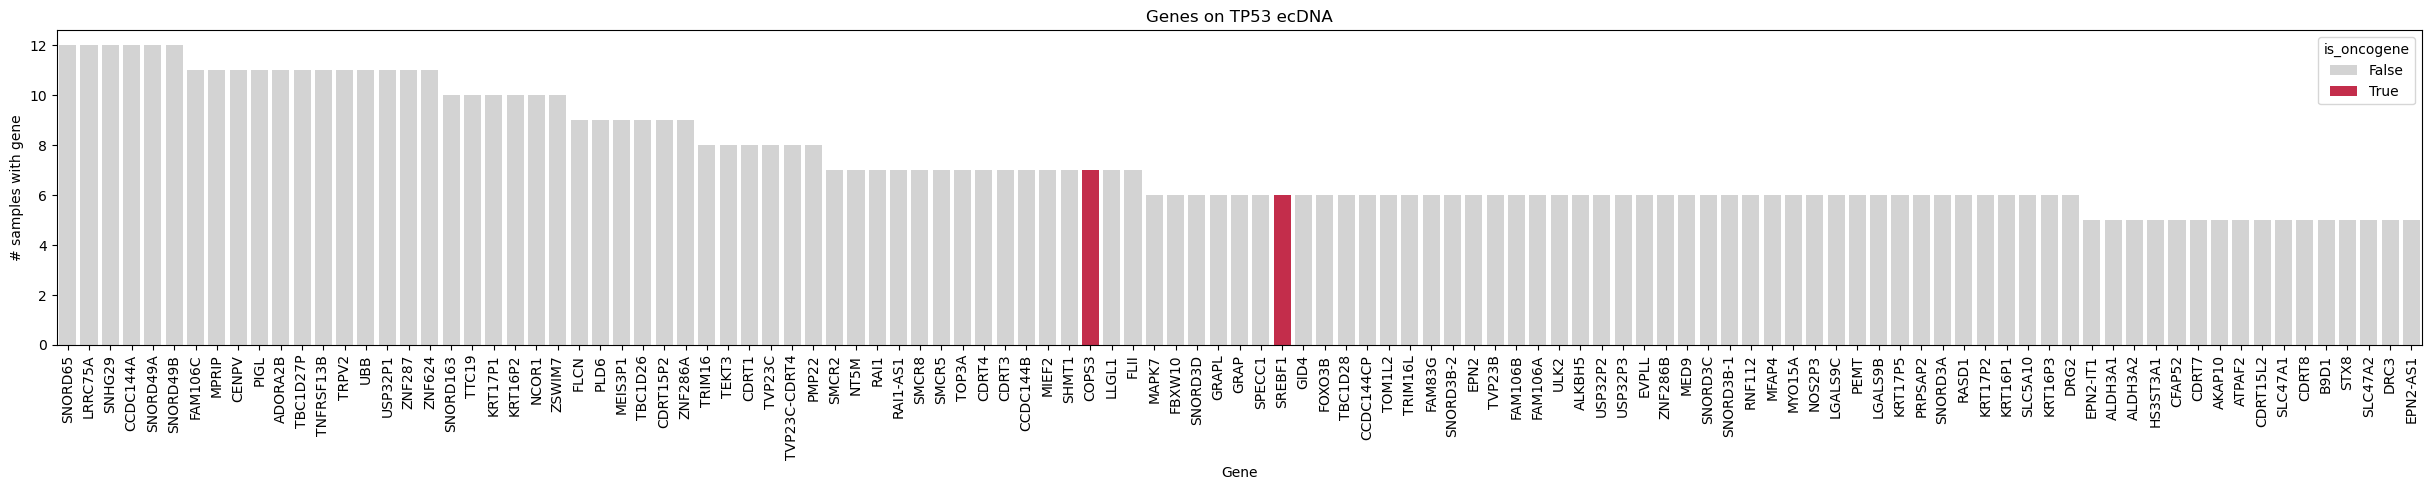

In [47]:
HOTSPOT = "TP53"

# pick the overlap column name
overlap_col = f"overlaps_{HOTSPOT}"

def as_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        x = x.strip()
        if x == "" or x == "[]":
            return []
        return ast.literal_eval(x)  # parses "['A','B']"
    return list(x)

df = ecDNA_filtered.copy()
df = df[df[overlap_col].astype(int) == 1].copy()

df["genes_list"] = df["All genes"].apply(as_list)
df["oncogenes_list"] = df["Oncogenes"].apply(as_list)

# add condition, where exclude events with a certain gene in the ecDNA
EXCLUDE_GENES = {""}
df["genes_list"] = df["All genes"].apply(as_list)
df = df[~df["genes_list"].apply(lambda genes: len(EXCLUDE_GENES.intersection(genes)) > 0)].copy()

# explode to one row per (sample, event, gene)
long = df[["Sample name", "Feature ID", "genes_list", "oncogenes_list"]].explode("genes_list")
long = long.rename(columns={"genes_list": "gene"})
long = long[long["gene"].notna() & (long["gene"] != "")].copy()

# gene is oncogene for that row if present in that event's oncogene list
long["is_oncogene_event"] = long.apply(lambda r: r["gene"] in set(r["oncogenes_list"]), axis=1)

gene_summary = (
    long.groupby("gene")
        .agg(
            n_samples=("Sample name", "nunique"),
            n_events=("Feature ID", "nunique"),
            is_oncogene=("is_oncogene_event", "any"),
        )
        .reset_index()
)

# restrict to genes in >3 samples
gene_summary = gene_summary[gene_summary["n_samples"] > 4].copy()
gene_summary = gene_summary.sort_values("n_samples", ascending=False)

# barplot: genes ordered by n_samples, colored by oncogene
plt.figure(figsize=(max(10, 0.22 * len(gene_summary)), 5))
ax = sns.barplot(
    data=gene_summary,
    x="gene",
    y="n_samples",
    hue="is_oncogene",
    order=gene_summary["gene"],
    dodge=False,
    palette={False: "lightgray", True: "crimson"},
)
ax.set_xlabel("Gene")
ax.set_ylabel("# samples with gene")
ax.set_title(f"Genes on {HOTSPOT} ecDNA")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
pat = re.compile(r"^(chr[0-9XYM]+):(\d+)-(\d+)$")

def chroms_in_locations(loc_list):
    """Return set of chromosomes present in a Location_list (parsed)."""
    if isinstance(loc_list, str):
        loc_list = ast.literal_eval(loc_list)
    chroms = set()
    for s in loc_list:
        m = pat.match(s)
        if m:
            chroms.add(m.group(1))
    return chroms

ecDNA_filtered["chroms"] = ecDNA_filtered["Location_list"].apply(chroms_in_locations)
ecDNA_filtered_multi = ecDNA_filtered[ecDNA_filtered["chroms"].apply(len) > 1]
print(f"ecDNA events with multiple chromosomes: {len(ecDNA_filtered_multi)}")
print(ecDNA_filtered_multi[["Sample name", "ecDNA context", "Oncogenes", "chroms"]].to_string(index=False))


ecDNA events with multiple chromosomes: 48
    Sample name                       ecDNA context                                                                                                                          Oncogenes                                        chroms
          09T02 Heavily rearranged multichromosomal                                                                                                                ['DNM2', 'SMARCA4']                                {chr19, chr21}
17_439_00067_T2                             Unknown                                                                                                          ['ETV3', 'NTRK1', 'PRCC']                                 {chr1, chr13}
          39T01 Heavily rearranged multichromosomal                                                                                                               ['MAP2K4', 'PRDM13']                                 {chr17, chr6}
 CCG1106_005_T1 Heavily rearranged multic